# Gemini 멀티모달 입력

이미지, PDF, 음성, 동영상과 텍스트를 함께 전달하고 Gemini가 여러 형태의 입력을 이해하는 과정을 확인합니다. 작은 파일은 Base64로 직접 전달하고, 다시 사용할 파일은 Files API에 업로드합니다.

### 실행 환경 준비

In [1]:
import base64
import mimetypes
import os
from pathlib import Path

from dotenv import load_dotenv
from google import genai
from IPython.display import Image, display

load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    raise ValueError(".env 파일에 GEMINI_API_KEY를 설정해 주세요.")

model = os.getenv("GEMINI_MODEL", "gemini-3.6-flash")
client = genai.Client(api_key=api_key)
print("준비 완료 / 사용 모델:", model)

준비 완료 / 사용 모델: gemini-3.6-flash


### 파일 입력 방법 비교

| 방법 | 전달 값 | 적합한 상황 |
| --- | --- | --- |
| Base64 | `data` | 작고 한 번만 사용할 파일 |
| Files API | `uri` | 크거나 여러 요청에서 재사용할 파일 |
| 공개 URL | `uri` | 인터넷에서 바로 접근할 수 있는 파일 |


### 로컬 이미지를 Base64로 전달하기

작은 로컬 이미지는 파일을 읽어 Base64 문자열로 변환한 뒤 `data`에 넣을 수 있습니다. 노트북과 같은 폴더에 분석할 이미지를 `sample.jpg`라는 이름으로 저장합니다.

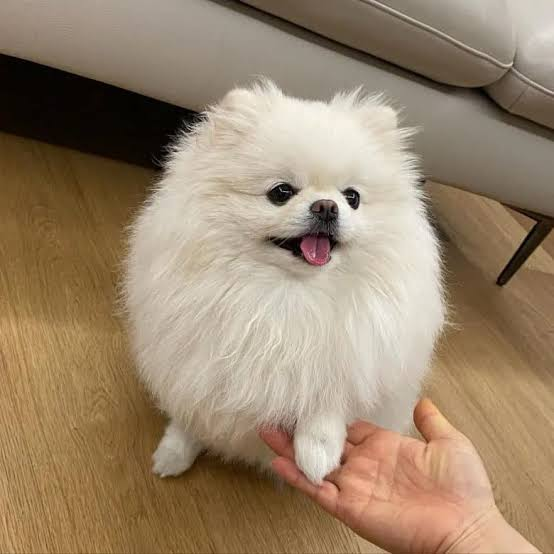

In [2]:
image_path = Path("sample.jpg")
if not image_path.exists():
    raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {image_path.resolve()}")

mime_type, _ = mimetypes.guess_type(image_path)
if mime_type not in {"image/jpeg", "image/png", "image/webp"}:
    raise ValueError("JPG, PNG 또는 WebP 이미지를 사용해 주세요.")

display(Image(filename=str(image_path), width=500))

In [3]:
image_data = base64.b64encode(image_path.read_bytes()).decode("utf-8")

local_interaction = client.interactions.create(
    model=model,
    input=[
        {
            "type": "image",
            "data": image_data,
            "mime_type": mime_type,
        },
        {
            "type": "text",
            "text": "이 이미지에 무엇이 보이는지 설명해 줘.",
        },
    ],
    store=False,
)

print(local_interaction.output_text)

이미지에는 매우 귀엽고 복실복실한 흰색 **포메라니안 강아지**가 사람과 교감하는 모습이 담겨 있습니다.

주요 특징은 다음과 같습니다:

* **강아지의 모습:** 마치 솜사탕이나 구름처럼 풍성한 하얀 털을 가지고 있습니다. 입을 살짝 벌린 채 분홍색 혀를 내밀고 있어 마치 밝게 웃고 있는 듯한 표정입니다. 까맣고 동그란 눈과 코가 매우 매력적입니다.
* **상호작용:** 사람이 손바닥을 위로 하여 펼치고 있고, 강아지가 한쪽 앞발을 사람의 손 위에 살포시 올려놓고 있습니다 ('손!' 장기를 부리거나 인사를 하는 모습입니다).
* **배경:** 따뜻한 느낌의 원목 마루 바닥 위에 강아지가 앉아 있으며, 뒤쪽에는 밝은 베이지색 소파의 아랫부분이 보입니다.

전체적으로 매우 사랑스럽고 따뜻하며 행복한 분위기를 주는 사진입니다.


### Files API로 이미지 전달하기

이미지를 Files API에 업로드한 뒤 발급받은 파일 URI를 `uri`에 지정합니다. 파일 업로드와 모델 요청은 서로 다른 작업이므로, 업로드한 파일 하나를 여러 질문에서 재사용할 수 있습니다.

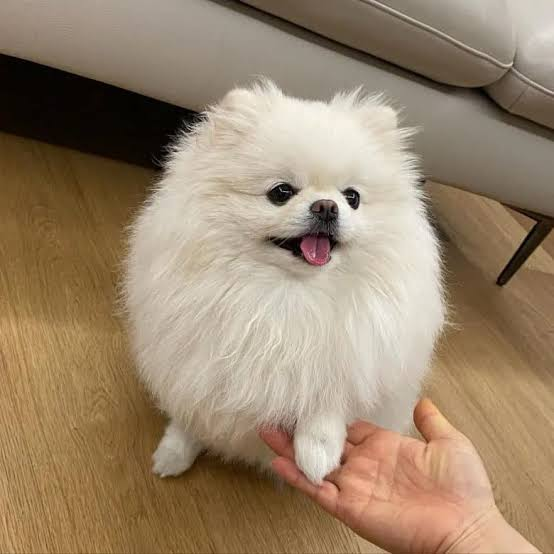

사진 속에는 매우 귀엽고 솜사탕처럼 푹신한 **하얀색 포메라니안 강아지**가 있습니다.

* **강아지의 표정과 행동:** 동그랗고 풍성한 흰 털을 가진 강아지가 까만 눈과 코, 살짝 나온 핑크빛 혀로 기분 좋게 웃는 듯한 표정을 짓고 있습니다. 사람의 손바닥 위에 자신의 작은 앞발을 살포시 올려놓고 '손!'을 하는 듯한 귀여운 포즈를 취하고 있습니다.
* **배경:** 깔끔하고 따뜻한 느낌의 원목 마루 바닥에 앉아 있으며, 뒤편에는 밝은 회색(베이지색) 가죽 소파가 보입니다.

전체적으로 강아지와 주인의 사랑스럽고 따뜻한 교감이 느껴지는 사진입니다.


In [4]:
image_path = Path("sample.jpg")
if not image_path.exists():
    raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {image_path.resolve()}")

display(Image(filename=str(image_path), width=500))
uploaded_file = client.files.upload(file=str(image_path))

url_interaction = client.interactions.create(
    model=model,
    input=[
        {
            "type": "image",
            "uri": uploaded_file.uri,
            "mime_type": uploaded_file.mime_type,
        },
        {
            "type": "text",
            "text": "이 이미지에 무엇이 보이는지 설명해 줘.",
        },
    ],
    store=False,
)

print(url_interaction.output_text)

### PDF·음성·동영상 업로드하기

Files API의 업로드 방법은 파일 종류와 관계없이 같습니다. 차이는 모델 입력에 지정하는 `type`입니다.

In [8]:
def input_type_from_mime(mime_type: str) -> str:
    if mime_type.startswith("image/"):
        return "image"
    if mime_type.startswith("audio/"):
        return "audio"
    if mime_type.startswith("video/"):
        return "video"
    return "document"


def analyze_file(file_path: str, prompt: str):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {path.resolve()}")

    uploaded = client.files.upload(file=str(path))
    input_type = input_type_from_mime(uploaded.mime_type)

    interaction = client.interactions.create(
        model=model,
        input=[
            {
                "type": input_type,
                "uri": uploaded.uri,
                "mime_type": uploaded.mime_type,
            },
            {"type": "text", "text": prompt},
        ],
        store=False,
    )
    return uploaded, interaction

In [9]:
uploaded_file, file_result = analyze_file(
    "sample.pdf",
    "문서의 핵심 내용을 세 문장으로 요약하고, 주요 일정을 표로 정리해 줘.",
)

print(file_result.output_text)

제시된 문서(성적우수상 상장)의 핵심 요약 및 주요 일정은 다음과 같습니다.

### **핵심 내용 요약 (3문장)**
1. 박의혁 훈련생이 (주)코리아아이티아카데미 대전에서 주관한 '(과정평가형) 정보처리산업기사 취득과정B'를 우수한 성적으로 이수하였습니다.
2. 해당 과정은 응용SW엔지니어링 직종에 해당하며, 2025년 8월 28일부터 2026년 2월 6일까지 약 5개월간 진행되었습니다.
3. 교육 과정을 성실히 완료하고 우수한 성적을 거둔 것을 격려하기 위해 2026년 2월 6일 자로 본 성적우수상을 수여하였습니다.

---

### **주요 일정**

| 구분 | 일정 | 상세 내용 |
| :--- | :--- | :--- |
| **훈련 시작일** | 2025년 8월 28일 | 교육 과정 개강 |
| **훈련 종료일** | 2026년 2월 6일 | 교육 과정 수료 |
| **상장 수여일** | 2026년 2월 6일 | 성적우수상 수여 |


### 업로드한 파일 확인하기

`files.get()`으로 업로드된 파일의 URI, MIME type과 처리 상태를 다시 확인할 수 있습니다.

In [10]:
file_metadata = client.files.get(name=uploaded_file.name)
print("이름:", file_metadata.name)
print("URI:", file_metadata.uri)
print("MIME type:", file_metadata.mime_type)
print("상태:", file_metadata.state.name if file_metadata.state else "상태 정보 없음")

이름: files/ifn7vppmwvbq
URI: https://generativelanguage.googleapis.com/v1beta/files/ifn7vppmwvbq
MIME type: application/pdf
상태: ACTIVE


### 이미지 생성하기

이미지 생성 모델에 장면을 설명하면 결과가 Base64 이미지로 반환됩니다. 생성된 이미지를 파일로 저장한 뒤 노트북에서 확인합니다.

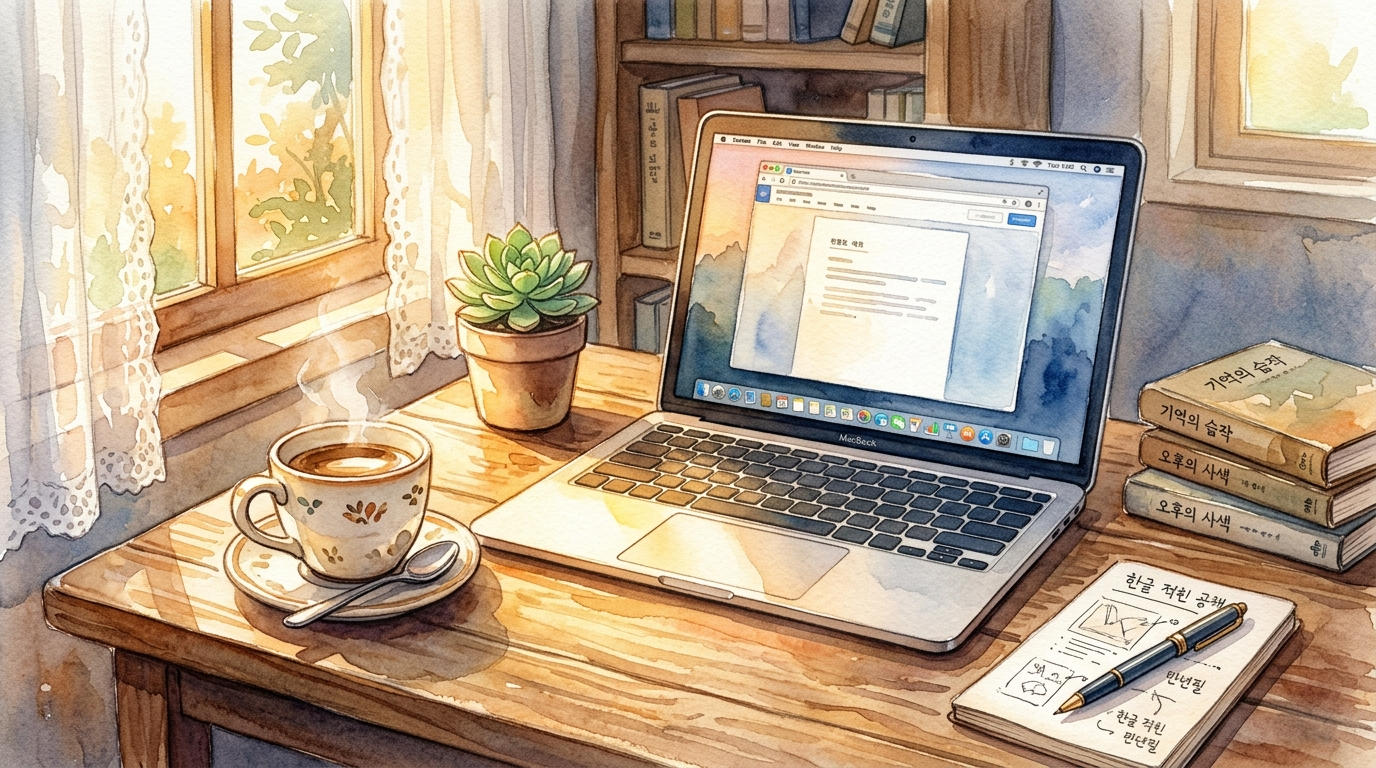

In [11]:
image_model = os.getenv("GEMINI_IMAGE_MODEL", "gemini-3.1-flash-image")
prompt = "따뜻한 오후 햇살이 비치는 책상 위의 노트북과 커피잔을 수채화 스타일로 그려 줘."

image_interaction = client.interactions.create(
    model=image_model,
    input=prompt,
    response_format={
        "type": "image",
        "mime_type": "image/jpeg",
        "aspect_ratio": "16:9",
    },
)

generated_path = Path("generated_image.jpg")
generated_path.write_bytes(
    base64.b64decode(image_interaction.output_image.data)
)

display(Image(filename=str(generated_path), width=700))

### 실습 문제

PDF, 음성 또는 동영상 중 하나를 선택해 다음 작업을 수행하세요.

- Files API로 파일을 업로드합니다.
- 파일 처리가 끝날 때까지 상태를 확인합니다.
- 파일 종류에 맞는 질문을 전달합니다.
- 같은 업로드 파일에 서로 다른 질문을 한 번 더 전달합니다.
- 두 응답의 입력·출력 토큰을 확인합니다.

In [13]:
def input_type_from_mime(mime_type: str) -> str:
    if mime_type.startswith("image/"):
        return "image"
    if mime_type.startswith("audio/"):
        return "audio"
    if mime_type.startswith("video/"):
        return "video"
    return "document"


def analyze_file(file_path: str, prompt: str):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {path.resolve()}")

    uploaded = client.files.upload(file=str(path))
    input_type = input_type_from_mime(uploaded.mime_type)

    interaction = client.interactions.create(
        model=model,
        input=[
            {
                "type": input_type,
                "uri": uploaded.uri,
                "mime_type": uploaded.mime_type,
            },
            {"type": "text", "text": prompt},
        ],
        store=False,
    )
    return uploaded, interaction

In [17]:
uploaded_file, file_result = analyze_file(
    "test.jpg",
    "이 사진이 무엇을 하고 있는지 알려주고, 분석해줘",
)

print(file_result.output_text)
print(file_result.usage)

제공해주신 사진은 **온라인으로 진행되는 AI 기술 강의(부트캠프/클래스) 현장 스크린샷**입니다. 

구체적으로 어떤 상황인지 항목별로 상세히 분석해 드립니다.

---

### 1. 주요 상황 요약
* **주제**: **인공지능(AI) 멀티모달(Multimodal) 모델 활용 개발 실습 강의**
* **진행 방식**: Zoom을 통한 실시간 화상 강의 + VS Code를 통한 코딩 실습 + 옵시디언(Obsidian)을 통한 공지 및 스케줄 안내

---

### 2. 화면 구성 요소별 상세 분석

#### ① 상단 및 우측: Zoom 화상 회의 (강의 진행)
* **참여자**: 상단에 'AI 에이전트 엔지니어 강사'를 포함하여 수강생 및 매니저(박의혁, 임대진, 곽준성, 박휘연, 김연준 등)가 접속해 있습니다.
* **우측 채팅창**: 강좌 시작 시 수강생들이 "안녕하세요"라고 인사를 나누는 채팅 기록이 보입니다.

#### ② 좌측 하단: VS Code (실습 코드 및 실습 문제)
* **작업 파일**: `multimodal.ipynb` (Jupyter Notebook 파일)
* **코드 내용**: 
  * 파이썬 코드를 통해 생성된 이미지(`generated_path`)를 화면에 출력(`display`)하고 있습니다.
  * 상단 경로(`python > gemini > ...`)를 볼 때 **구글 Gemini(제미나이) 멀티모달 API**를 활용한 수업으로 추정됩니다.
* **실습 문제**: 
  * *"PDF, 음성 또는 동영상 중 하나를 선택해 다음 작업을 수행하세요."*라는 과제가 제시되어 있습니다. 텍스트뿐만 아니라 다양한 매체(이미지, 파일, 음성 등)를 처리하는 멀티모달 AI 활용 실습입니다.

#### ③ 중앙: 옵시디언(Obsidian) (강의 안내 노트)
* **노트 제목**: **복습 및 문제풀이 시간**
* **내용**: 
  * `10:50`에 "멀티모달 복습하기"를 진행할 예정임을 안내하고 있습니다.
* **팝업창**: 옵시디언 